## RNN (by Tensorflow)

In [1]:
# 사용할 상수 정의 

VOCAB_SIZE = 300  # 어휘 사전의 크기(사용할 단어 수)
SEQ_LENGTH = 100  # 시퀀스 하나의 최대 길이

### 데이터 준비

In [2]:
from tensorflow.keras.datasets import imdb 

# imdb : 인터넷 영화 데이터베이스
# 각 데이터는 (리뷰 내용, 리뷰 레이블)로 구성
# 긍정/부정 리뷰 데이터셋 제공
# 레이블 : 0(부정), 1(긍정)
# 훈련 데이터 25,000개, 테스트 데이터 25,000개로 구성
# 데이터는 이미 정수 인코딩(단어를 정수로 변환)되어 있음
# 데이터셋은 keras.datasets.imdb 모듈에서 제공
# 튜플의 형태로 (훈련 데이터, 테스트 데이터) 제공

# load_data() : imdb 데이터셋을 불러오는 함수
#     - num_words : 자주 등장하는 단어 순서대로 몇 개의 단어를 사용할지 지정
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=VOCAB_SIZE)
  


In [3]:
train_input, test_input = train_input[:10000], test_input[:5000]
train_target, test_target = train_target[:10000], test_target[:5000]

In [4]:
len(train_input[0]), len(train_input[1])

(218, 189)

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 시퀀스 길이 맞추기 => 왜? RNN 모델에 입력하려면 시퀀스 길이가 같아야 하기 때문
train_seq = pad_sequences(train_input, maxlen=SEQ_LENGTH)
test_seq = pad_sequences(test_input, maxlen=SEQ_LENGTH)

train_seq.shape, test_seq.shape

((10000, 100), (5000, 100))

In [6]:
# 원핫 인코딩 => 희소 행렬로 변환 => RNN 모델에 입력하려면 단어를 원핫 인코딩된 벡터로 변환해야 하기 때문
from tensorflow.keras.utils import to_categorical

train_onehot = to_categorical(train_seq)
test_onehot = to_categorical(test_seq)

train_onehot.shape, test_onehot.shape


((10000, 100, 300), (5000, 100, 300))

### 모델 준비 및 학습

In [7]:
from tensorflow.keras import models, layers, callbacks, optimizers

# layers.Input : 모델의 입력층을 정의하는 클래스
#     - shape : 입력 데이터의 형태 지정
#        (SEQ_LENGTH, VOCAB_SIZE) : 시퀀스 길이, 원핫 벡터 크기 
# 모델의 출력 값을 0과 1 사이로 변환
# 모델의 출력이 특정 클래스(긍정 또는 부정)에 속할 확률을 나타냄
input = layers.Input(shape=(SEQ_LENGTH, VOCAB_SIZE))  

# layers.SimpleRNN : RNN 층을 만드는 클래스
#     - units : RNN 층의 뉴런 개수(출력 차원)
x = layers.SimpleRNN(units=8)(input)

# layers.Dense : 출력층을 만드는 클래스
#    - activation : 활성화 함수 지정
#       'sigmoid' : 이진 분류에서 주로 사용되는 활성화 함수
output = layers.Dense(1, activation='sigmoid')(x)

# 모델 생성
# 입력층, RNN 층, 출력층을 연결하여 모델을 생성
model = models.Model(inputs=input, outputs=output)
model.summary() # 모델 구조 출력 

# [결과 해설]
# 300개의 단어로 구성된 시퀀스를 입력으로 받아 8개의 뉴런을 가진 RNN 층을 통과시킨 후,
# 마지막으로 시그모이드 활성화 함수를 사용하여 이진 분류를 수행
# 모델의 총 파라미터 수는 2,472개
# 300 * 8 (입력 가중치 = 은닉층) + 8 * 8 (재귀 가중치) + 8 (편향) = 2,472


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 300)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         2,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,481 (9.69 KB)

 Trainable params: 2,481 (9.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5242 - loss: 0.6948 - val_accuracy: 0.5755 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6386 - loss: 0.6492 - val_accuracy: 0.6925 - val_loss: 0.6244 - learning_rate: 0.0010
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7113 - loss: 0.5960 - val_accuracy: 0.7240 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7334 - loss: 0.5575 - val_accuracy: 0.7400 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7492 - loss: 0.5332 - val_accuracy: 0.7435 - val_loss: 0.5384 - learning_rate: 0.0010
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7581 - loss: 0.5199 - val_accuracy: 0.7425 - val_loss: 0.5382 - learning_rate: 0.0010
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7661 - lo

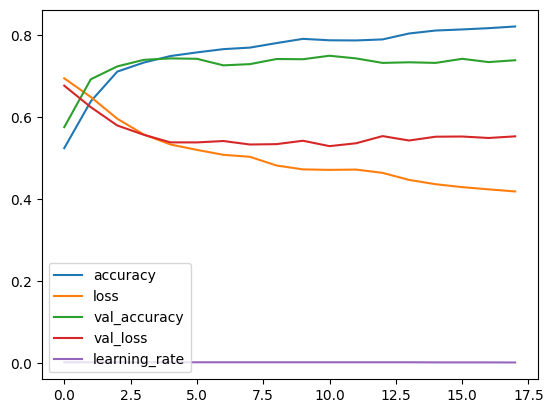

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

model.compile(
    loss='binary_crossentropy', # 이진 분류 문제에서 주로 사용되는 손실 함수
    optimizer='adam', # Adam 옵티마이저 사용
    metrics=['accuracy'] # 모델 평가에 사용할 지표로 정확도 선택
    )

# 조기 종료 콜백 설정
early_stopping = callbacks.EarlyStopping(
    verbose=1, # 훈련 중단 시 메시지 출력
    patience=7, # 7 에포크 동안 개선이 없으면 훈련 중단
    restore_best_weights=True # 가장 좋은 가중치 복원
)

reduce_lr_on_plateau_cb = callbacks.ReduceLROnPlateau( 
    factor=0.7, # 학습률 감소 비율
    patience=3, # 3 에포크 동안 개선이 없으면 학습률 감소
    verbose=1 # 학습률 감소 시 메시지 출력
)

history = model.fit(
    train_onehot, # 훈련 입력 데이터
    train_target, # 훈련 레이블
    epochs=100, # 에포크 수
    batch_size=65, # 배치 크기
    validation_split=0.2, # 검증 데이터 비율
    callbacks=[early_stopping, reduce_lr_on_plateau_cb] # 콜백 함수 목록
)   

history_df = pd.DataFrame(history.history)
history_df.plot()
plt.show()

In [9]:
loss, accuracy = model.evaluate(test_onehot, test_target)
loss, accuracy

# [ 결론 ]
# tensorflow라는 구조를 사용해서 RNN 모델을 구현하고 학습시켰다.

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7368 - loss: 0.5567


(0.5566558241844177, 0.7368000149726868)